In [1]:
import urllib.request as request
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0101EN-SkillsNetwork/labs/Module%204/data/example1.txt'

filename = 'Example1.txt'
request.urlretrieve(url, filename)


('Example1.txt', <http.client.HTTPMessage at 0x7964e017e350>)

In [2]:
#!pip install pyodide-build

In [3]:
import os

For opening and writing to files, we are safe using the with context manager.

The context manager handles opening and closing of files automatically.

In [4]:
with open('Example1.txt') as file1:
    fileContent = file1.readlines()

In [5]:
fileContent
len(fileContent)

3

In [6]:
with open('Example1.txt','r') as file2:
    lines = file2.read()

In [7]:
print(lines)

This is line 1 
This is line 2
This is line 3


In [8]:
with open("Example1.txt","r") as txt:
    file_ = txt.readlines()
    for i, line in enumerate(file_, start =0):
        print(f"Iteration {i} {line}")
        

Iteration 0 This is line 1 

Iteration 1 This is line 2

Iteration 2 This is line 3


In [9]:
file_

['This is line 1 \n', 'This is line 2\n', 'This is line 3']

**readlines()** returns a list object

**read()** returns a string object

## File opening and reading modes:

r - reading

w - writing

a - appending plus updating

b - binary file

a+ read or append

r+ read and write


In [47]:
with open("balances_erp.csv","r") as text_file:
    content = text_file.readline()
    print(content)

Party Type,Party,Supplier Name,Advance Amount,Invoiced Amount,Paid Amount,Outstanding Amount,Total Amount Due



file.readlines() - reads all lines as a list

file.readline() reads the next line as a string

file.read() reads the entire file content as a string

In [40]:
with open("balances_erp.csv","r") as file:
    lines = file.readlines()
    next_line = file.readline()
    content = file.read()

In [41]:
len(lines)

53

In [42]:
next_line

''

In [38]:
content

''

#### File writing modes

file.write(content)  ## writes a string to the file

file.writelines(lines) ## writes a list of strings to the file

In [43]:
lines = ["Hello\n","My friend\n"]
with open("output.txt","w") as file:
    file.writelines(lines)

In [51]:
## with context manager ensures automatic closure of the file after opening it

with open("output.txt","a+") as file_:
    file_.seek(0) ## move the pointer to the beginning of the file
    for line in file_:
        print(line)

Hello

My friend



In [52]:
!ls

 balances_erp.csv
 birthdays.py
 Class_coding.ipynb
 configs.py
 data
 Example1.txt
'Exception Handling and Debugging.ipynb'
 metabase_balance.csv
 MorePandas.ipynb
 Numpy_fundementals.ipynb
 openWeatherApi.py
 output.txt
'Payables analysis.ipynb'
 picnicTable.py
 __pycache__
'Python Fundamentals Core.txt'
 query_result_2026-07-29T12_37_11.260560335Z.ods
'Salary Register.xlsx'
 sql_in_de.txt
 validateInput.py
 warehouse_tables.sql
 Working_with_data_and_files.ipynb


In [53]:
import pandas as pd

pd.read_csv()  --> read csv file

pd.read_excel() --> read excel file

df.to_csv()  --> Save file as csv

df.to_excel() --> Save file as excel

DataFrame.axis = 0 refers to rows

DataFrame.axis = 1 refers to columns

df.dropna() removes rows with missing values or NaN values from the DataFrame, axis = 0 indicates to remove NaN rows, axis = 1 would
            indicate to remove NaN columns

In [57]:
upload_file = pd.read_excel('Salary Register.xlsx',sheet_name='Payroll Upload File August 2026')

In [58]:
upload_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 566 entries, 0 to 565
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Payroll No       551 non-null    object 
 1   Employee Name    563 non-null    object 
 2   Net Pay          563 non-null    float64
 3   Bank Account No  551 non-null    object 
 4   Bank Name        551 non-null    object 
dtypes: float64(1), object(4)
memory usage: 22.2+ KB


In [61]:
upload_file = upload_file[upload_file["Payroll No"].notna()]

In [62]:
upload_file["Net Pay"].sum()

np.float64(12265476.0)

In [63]:
sum(upload_file["Net Pay"])

12265476.0

In [71]:
upload_file[~upload_file["Payroll No"].str.startswith("Casual")]

,Payroll No,Employee Name,Net Pay,Bank Account No,Bank Name
0,NM000,Peter Muchoki Ndiangui,105224.0,00204043396150,I&M BANK
1,NM002,Belinda Nduume Mbithi,12619.0,00104065226150,I&M BANK
2,NM006,Meshack Wambua,21098.0,03104059936150,I&M BANK
3,NM007,Sammy Mandex Osama,92639.0,00204043066150,I&M BANK
4,NM008,Samuel Mwangi Ngunyi,43577.0,00104074636150,I&M BANK
...,...,...,...,...,...
434,NM619,VICTOR ASHOMBE,25386.0,07610122936150,I&M BANK
435,NM620,JOSEPH MUIRURI WANYOIKE,14360.0,00104038066150,I&M BANK
436,NM621,DAVID ONYANGO OBIERO,17029.0,00104062376150,I&M BANK
437,Intern.01,Cliff Kimama Maina,10000.0,07610170996150,I&M BANK


In [72]:
upload_file.duplicated(subset=["Payroll No"])

0      False
1      False
2      False
3      False
4      False
       ...  
546    False
547    False
548    False
549    False
550    False
Length: 551, dtype: bool

In [82]:
upload_file[(upload_file["Net Pay"] >= 90000) & (upload_file["Bank Name"] != "ABSA")]

,Payroll No,Employee Name,Net Pay,Bank Account No,Bank Name
0,NM000,Peter Muchoki Ndiangui,105224.0,00204043396150,I&M BANK
3,NM007,Sammy Mandex Osama,92639.0,00204043066150,I&M BANK
5,NM009,Joseph Kilonzi Musyoka,114676.0,00104059266150,I&M BANK
9,NM014,Stephen Njenga Waweru,121714.0,00103964796150,I&M BANK
20,NM026,Eric Njiru Nthia,178388.0,00104068306150,I&M BANK
22,NM028,Moses Odhiambo Agugo,92737.0,00104082156150,I&M BANK
31,NM037,Colly Fiona Nafula,225577.0,00204043846150,I&M BANK
33,NM039,George Oduor Ogilo,90639.0,04003842856150,I&M BANK
48,NM0552,Chelangat Brenda,134915.0,00408462916150,I&M BANK
71,NM0578,Yvonne Saula,123562.0,06608391236151,I&M BANK


In [87]:
upload_file.groupby(["Bank Name"])["Net Pay"].mean()

Bank Name
ABSA        172739.000000
I&M BANK     22901.726397
MPESA         6669.064516
Name: Net Pay, dtype: float64

In [88]:
upload_file.rename(columns = {"Net Pay":"net_pay"}, inplace=True)

In [91]:
upload_file.groupby(["Bank Name"]).agg({"net_pay":"sum"}).reset_index()

,Bank Name,net_pay
0,ABSA,172739.0
1,I&M BANK,11885996.0
2,MPESA,206741.0


In [118]:
import numpy as np
x = np.linspace(0,np.pi,20)

In [119]:
y = np.sin(x)

In [120]:
y

array([0.00000000e+00, 1.64594590e-01, 3.24699469e-01, 4.75947393e-01,
       6.14212713e-01, 7.35723911e-01, 8.37166478e-01, 9.15773327e-01,
       9.69400266e-01, 9.96584493e-01, 9.96584493e-01, 9.69400266e-01,
       9.15773327e-01, 8.37166478e-01, 7.35723911e-01, 6.14212713e-01,
       4.75947393e-01, 3.24699469e-01, 1.64594590e-01, 1.22464680e-16])

In [121]:
import matplotlib.pyplot as plt

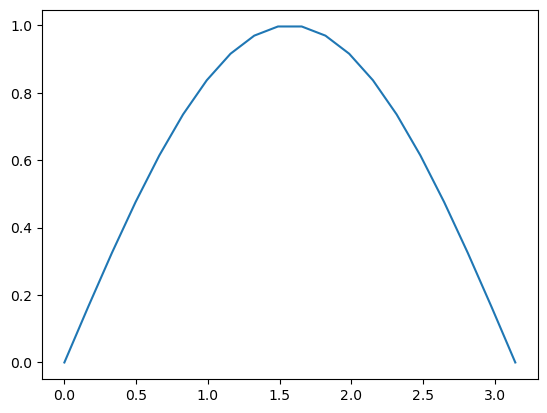

In [122]:
plt.plot(x, y)